# Image Duplicates & Near Duplicates

This example shows how SentenceTransformers can be used to find image duplicates and near duplicates.

As model, we use the [OpenAI CLIP Model](https://github.com/openai/CLIP), which was trained on a large set of images and image alt texts.  
Note that the CLIP is now from 2021 and more recent models exist. We use it for this illustration because it is small and therefore run on a Google Colab GPU.  
As an alternative, you can check the models with the [`zero-shot-image-classification`](https://huggingface.co/models?pipeline_tag=zero-shot-image-classification) pipeline tag on the 🤗 Hub.  
You can also test [trimmed](https://huggingface.co/blog/lbourdois/introduction-to-trimming) models that have the advantage of being smaller than the models from which they are derived while keeping the same performance. To find these models, we invite you to look at the `visual embedding` models listed in this [Space](https://huggingface.co/spaces/alphaedge-ai/Trimming_models_search).

As a source for photos, we use the [Unsplash Dataset Lite](https://unsplash.com/data), which contains about 25k images. See the [License](https://unsplash.com/license) about the Unsplash images.

We encode all images into vector space and then look for pairs of images with a very high cosine similarity, i.e. (near-)identical photos.

In [ ]:
from datasets import load_dataset
from IPython.display import display

from sentence_transformers import SentenceTransformer
from sentence_transformers.util import paraphrase_mining_embeddings

In [ ]:
# First, we load the respective CLIP model
model = SentenceTransformer("sentence-transformers/clip-ViT-B-32")

In [ ]:
# Next, we load the Unsplash Dataset Lite
unsplash = load_dataset("sentence-transformers/unsplash-lite")

# We can see that the dataset contains a column containing the images
# but also a column containing keywords that we will not use here.
unsplash

DatasetDict({
    train: Dataset({
        features: ['image', 'keywords'],
        num_rows: 24996
    })
})

In [ ]:
# Now, we need to compute the embeddings
# The attached function will be required for the following cell
# in the case where precomputed embeddings are not used .
embeddings_name = "embeddings_clip-ViT-B-32"


def embed(batch):
    """
    adds to the dataset a column of embeddings of images calculated with the model
    """
    image = batch["image"]
    return {embeddings_name: model.encode(image, convert_to_tensor=True)}

In [ ]:
# Here for the calculation of the embeddings, you have 2 choices:
# 1) `use_precomputed_embeddings = True` and in that case you can
# use embeddings that we have already pre-calculated in order to speed up
# the execution of the notebook.
# 2) `use_precomputed_embeddings = False` and compute the embeddings on the fly.
# Takes about 9 minutes on a Google Colab T4

use_precomputed_embeddings = True

if use_precomputed_embeddings:
    embeddings_ds = load_dataset("sentence-transformers/unsplash-lite", name=embeddings_name, split="train")
    unsplash["train"] = unsplash["train"].add_column(embeddings_name, embeddings_ds[embeddings_name])

else:
    unsplash = unsplash.map(embed, batched=True, batch_size=16)

    # Uncomment the rest of the else condition if you want to save the embeddings
    # on the Hub to use `use_precomputed_embeddings = True` in the future

    # # We delete 'image' and 'keywords' so as not to save them as duplicates unnecessarily
    # embeddings_ds = unsplash['train'].remove_columns(['image', 'keywords'])
    # embeddings_ds.push_to_hub(
    #     "your_username/unsplash-lite", # your username
    #     config_name=embeddings_name,
    #     split="train",
    #     token="hf_xx" # your HF token
    # )

# We now have a new column containing our embeddings
unsplash

DatasetDict({
    train: Dataset({
        features: ['image', 'keywords', 'embeddings_clip-ViT-B-32'],
        num_rows: 24996
    })
})

In [ ]:
# Now we mine for the most similar image pairs across the whole collection.
# paraphrase_mining_embeddings compares the images and returns the pairs with the
# highest cosine similarity, sorted from most to least similar.

img_emb = unsplash["train"][embeddings_name]
duplicates = paraphrase_mining_embeddings(img_emb)

# duplicates contains a list with triplets (score, image_id1, image_id2) and is sorted in decreasing order

## Duplicates
In the next cell, we output the top 10 most similar images. These are identical images,
i.e. the same photo was uploaded twice to Unsplash


Score: 1.000
Image  283


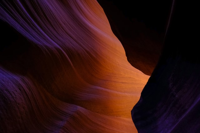

Image  14143


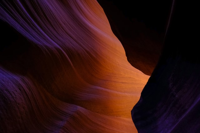


Score: 1.000
Image  5179


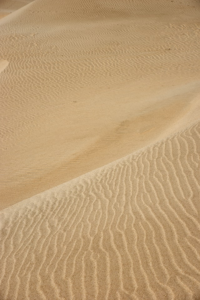

Image  15642


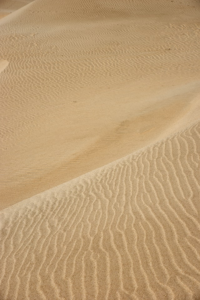


Score: 1.000
Image  5179


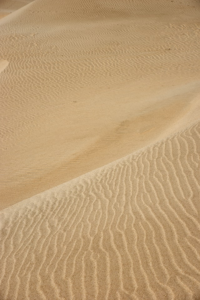

Image  18968


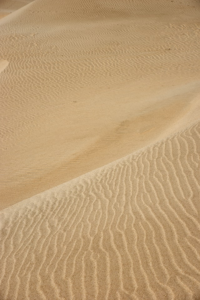


Score: 1.000
Image  15642


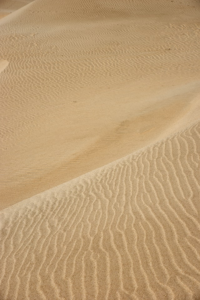

Image  18968


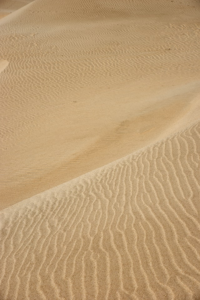


Score: 1.000
Image  1372


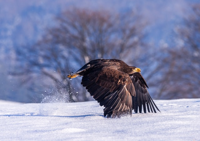

Image  17889


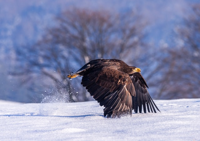


Score: 1.000
Image  2184


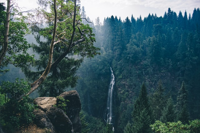

Image  16811


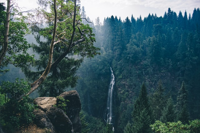


Score: 1.000
Image  2903


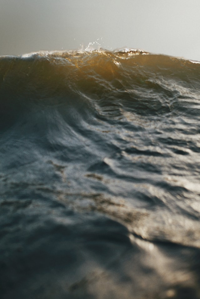

Image  4246


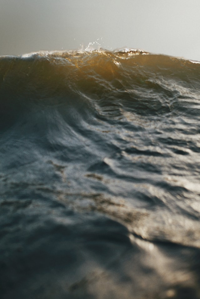


Score: 1.000
Image  4580


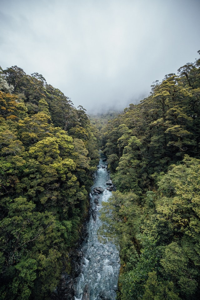

Image  7871


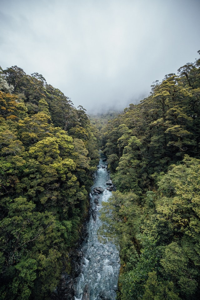


Score: 1.000
Image  5154


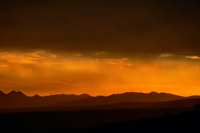

Image  20925


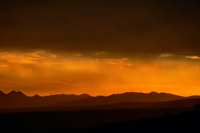


Score: 1.000
Image  15796


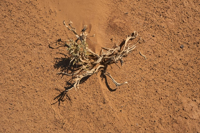

Image  16943


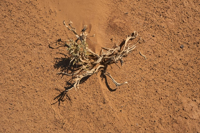

In [ ]:
for score, idx1, idx2 in duplicates[0:10]:
    print(f"\nScore: {score:.3f}")
    print("Image ", idx1)
    # # original size
    # display(unsplash["train"][idx1]["image"])
    # # width=200px
    display(
        unsplash["train"][idx1]["image"].resize(
            (200, int(200 * unsplash["train"][idx1]["image"].height / unsplash["train"][idx1]["image"].width))
        )
    )

    print("Image ", idx2)
    # # original size
    # display(unsplash["train"][idx2]["image"])
    # # width=200px
    display(
        unsplash["train"][idx2]["image"].resize(
            (200, int(200 * unsplash["train"][idx2]["image"].height / unsplash["train"][idx2]["image"].width))
        )
    )

## Near Duplicates
We can also skip the duplicate images and find near duplicates.
To achieve this, we only look at images pairs that have a cosine similarity below a certain threshold.
In our example, we look at images with a cosine similarity lower than 0.99


Score: 0.989
Image  11900


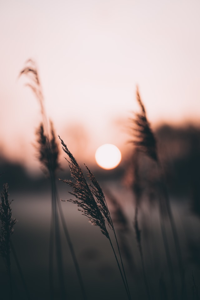

Image  17864


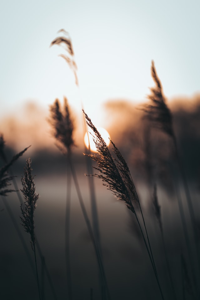


Score: 0.989
Image  377


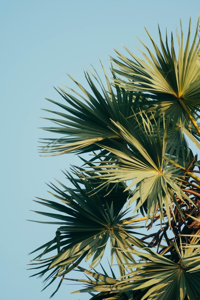

Image  19632


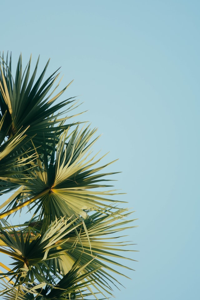


Score: 0.988
Image  16929


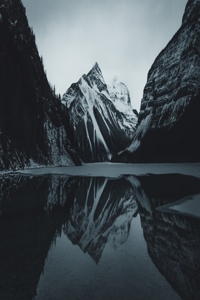

Image  20068


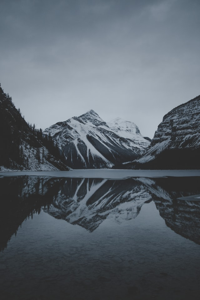


Score: 0.987
Image  6080


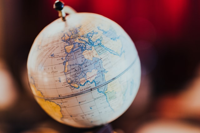

Image  7556


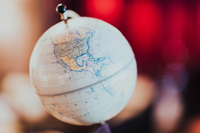


Score: 0.987
Image  9853


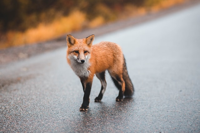

Image  17081


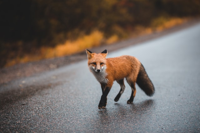


Score: 0.987
Image  959


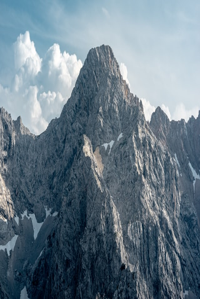

Image  8785


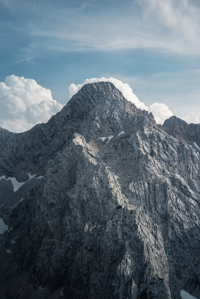


Score: 0.987
Image  18014


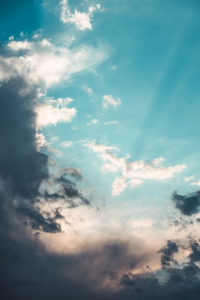

Image  24365


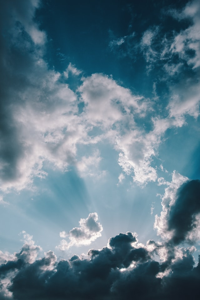


Score: 0.987
Image  3932


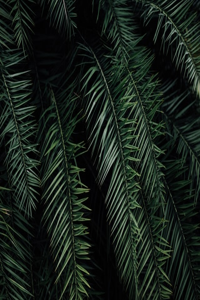

Image  21092


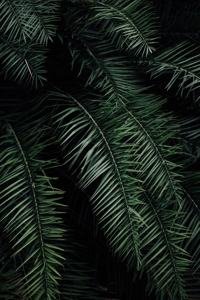


Score: 0.986
Image  4100


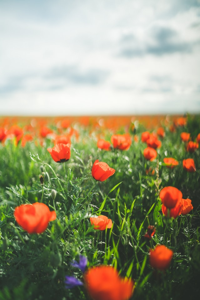

Image  13820


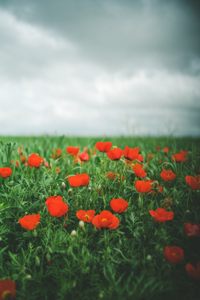


Score: 0.986
Image  8620


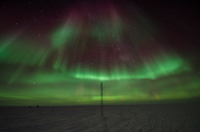

Image  18043


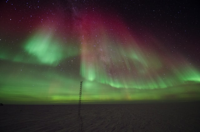

In [ ]:
threshold = 0.99
near_duplicates = [entry for entry in duplicates if entry[0] < threshold]

for score, idx1, idx2 in near_duplicates[0:10]:
    print(f"\nScore: {score:.3f}")
    print("Image ", idx1)
    # # original size
    # display(unsplash["train"][idx1]["image"])
    # # width=200px
    display(
        unsplash["train"][idx1]["image"].resize(
            (200, int(200 * unsplash["train"][idx1]["image"].height / unsplash["train"][idx1]["image"].width))
        )
    )

    print("Image ", idx2)
    # # original size
    # display(unsplash["train"][idx2]["image"])
    # # width=200px
    display(
        unsplash["train"][idx2]["image"].resize(
            (200, int(200 * unsplash["train"][idx2]["image"].height / unsplash["train"][idx2]["image"].width))
        )
    )